# Installation

```bash
git clone https://github.com/jbirky/alabi
cd alabi
python setup.py install
```

# Quickstart Example

### Step 1

Import python modules:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from alabi.core import SurrogateModel
import multiprocessing as mp

np.random.seed(7)

### Step 2

Define the test function and the bounds for the input space. For example:

In [5]:
def test1d_fn(x):
    return np.sin(5 * x) * (1 - np.tanh(x**2))

bounds = [(-1, 1)]

### Step 3

Initialize the surrogate model, specifying the function to train on, the bounds of the input space, and directory where the results will be saved:

In [6]:
sm = SurrogateModel(lnlike_fn=test1d_fn, bounds=bounds, savedir=f"results/test1d")

### Step 4

Initialize the gaussian process surrogate model by specifying a kernel. In this example we'll use a squared exponential kernel:

$ k(x, x') = \sigma_f^2 \exp\left(-\frac{(x - x')^2}{2\ell^2}\right) $

where $ k(x, x') $ is the kernel function, $ \sigma_f^2 $ is the amplitude hyperparameter, $ \ell $ is the length scale hyperparameter, and $ x $ and $ x' $ are input points.

In [7]:
sm.init_samples(ntrain=10)
sm.init_gp(kernel="ExpSquaredKernel", fit_amp=True, fit_mean=True, hyperopt_method="ml", overwrite=True)

Initialized GP with squared exponential kernel.
Successfully initialized GP on attempt 1


Optimizing GP: 100%|██████████| 3/3 [00:00<00:00, 47.47it/s]

Initial -logL: 	 9.9037 | 	 Regularization: 1.3521 | 	 Total: 11.2558
Final -logL: 	 -12.6715 | 	 Regularization: 1.3250 | 	 Total: -11.3465 
11 iterations | Success: True | Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH 



### Step 5

Improve the surrogate model fit by iteratively selecting new training points using active learning:

In [8]:
sm.active_train(niter=30, algorithm="bape", gp_opt_freq=10)

Running 30 active learning iterations using bape...


 33%|███▎      | 10/30 [00:00<00:00, 67.36it/s]

Initial -logL: 	 -63.6846 | 	 Regularization: 1.3250 | 	 Total: -62.3595
Final -logL: 	 -64.3688 | 	 Regularization: 1.3393 | 	 Total: -63.0294 
4 iterations | Success: True | Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH 

Train MSE: 8.812870074515294e-10


 67%|██████▋   | 20/30 [00:00<00:00, 74.13it/s]

Initial -logL: 	 -125.4754 | 	 Regularization: 1.3393 | 	 Total: -124.1361
Final -logL: 	 -125.4860 | 	 Regularization: 1.3405 | 	 Total: -124.1455 
14 iterations | Success: True | Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH 

Train MSE: 1.1543872320842774e-09


100%|██████████| 30/30 [00:02<00:00, 10.87it/s]

Initial -logL: 	 -190.0018 | 	 Regularization: 1.3405 | 	 Total: -188.6613
Final -logL: 	 -190.0063 | 	 Regularization: 1.3413 | 	 Total: -188.6649 
1 iterations | Success: False | Message: ABNORMAL:  

Train MSE: 1.0655499724350785e-09
Caching model to results/test1d/surrogate_model...


### Step 6

Run Markov Chain Monte Carlo (MCMC) sampler using either the `emcee` package:

In [10]:
sm.run_emcee(nwalkers=4, nsteps=int(5e4))

Initializing emcee with self.surrogate_log_likelihood surrogate model as likelihood.
No prior_fn specified. Defaulting to uniform prior with bounds [[-1  1]]
Running emcee with 4 walkers for 50000 steps on 1 cores...

Run 1: Need 10000 more samples...


100%|██████████| 50000/50000 [00:51<00:00, 965.96it/s] 


burn-in estimate: 114
thin estimate: 28

Run 1 complete: 7124 samples
Total accumulated samples: 7124

Run 2: Need 2876 more samples...


100%|██████████| 50000/50000 [00:51<00:00, 971.73it/s]


burn-in estimate: 109
thin estimate: 27

Run 2 complete: 7388 samples
Total accumulated samples: 14512

Combined 2 runs into 14512 total samples
Total samples: 14512
Mean acceptance fraction: 0.699
Mean autocorrelation time: 54.539 steps
Caching model to results/test1d/surrogate_model...
Saving final emcee samples to results/test1d/emcee_samples_final_surrogate_iter_30.npz ...


In [11]:
sm.run_dynesty()

Initializing dynesty with self.surrogate_log_likelihood surrogate model as likelihood.
Initialized dynesty DynamicNestedSampler.
Running dynesty with 50 live points on 1 cores...

Run 1: Need 10000 more samples...


10189it [00:09, 1024.94it/s, batch: 79 | bound: 0 | nc: 1 | ncall: 23337 | eff(%): 43.660 | loglstar:   -inf <  0.909 <  0.298 | logz:  0.134 +/-  0.021 | stop:  0.991]


Run 1 complete: 10189 samples, logZ = 0.134
Total accumulated samples: 10189
Caching model to results/test1d/surrogate_model...
Saved dynesty samples to results/test1d/dynesty_samples_final_surrogate_iter_30.npz


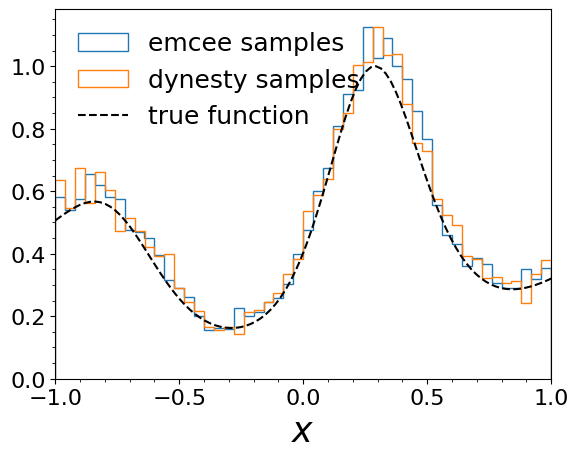

In [18]:
xgrid = np.linspace(bounds[0][0], bounds[0][1], 100)
ygrid = np.exp(test1d_fn(xgrid))

plt.hist(sm.emcee_samples.T[0], bins=50, histtype='step', density=True, label="emcee samples")
plt.hist(sm.dynesty_samples.T[0], bins=50, histtype='step', density=True, label="dynesty samples")
plt.plot(xgrid, ygrid/max(ygrid), label="true function", color="k", linestyle="--")
plt.xlabel("$x$", fontsize=25)
plt.xlim(*bounds)
plt.legend(loc="upper left", fontsize=18, frameon=False)
plt.minorticks_on()
plt.show()